In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from scipy import stats



In [2]:
import pandas as pd

df = pd.read_csv("../data/outputs/provider_month.csv")
df

,billing_provider_npi,cohort_label,month,paid_t,claims_t,hcpcs_count_t,paid_per_claim_t,top_code_paid_share,top_3_code_paid_share,hcpcs_entropy,hcpcs_hhi,beneficiaries_proxy_t,claims_per_beneficiary_proxy_t,paid_per_beneficiary_proxy_t,label,excldate
0,1003006180,NV_organization,2018-01-01,671415.34,6610,7,101.575694,0.749187,0.934509,0.911755,0.580282,5498,1.202255,122.119924,0,NaN
1,1003006180,NV_organization,2018-02-01,509838.42,5053,7,100.898163,0.683650,0.915130,1.079675,0.496263,4268,1.183927,119.456050,0,NaN
2,1003006180,NV_organization,2018-03-01,516444.10,5386,7,95.886391,0.671772,0.898001,1.129894,0.479706,4597,1.171634,112.343724,0,NaN
3,1003006180,NV_organization,2018-04-01,563348.08,5796,7,97.196011,0.616892,0.903758,1.202937,0.426552,4890,1.185276,115.204106,0,NaN
4,1003006180,NV_organization,2018-05-01,562713.35,5758,7,97.727223,0.619411,0.894353,1.219314,0.425726,4798,1.200083,117.280815,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164844,1992920698,NV_organization,2024-08-01,4669.22,31,1,150.620000,1.000000,1.000000,0.000000,1.000000,31,1.000000,150.620000,0,NaN
164845,1992920698,NV_organization,2024-09-01,5572.94,37,1,150.620000,1.000000,1.000000,0.000000,1.000000,37,1.000000,150.620000,0,NaN
164846,1992920698,NV_organization,2024-10-01,5874.18,39,1,150.620000,1.000000,1.000000,0.000000,1.000000,39,1.000000,150.620000,0,NaN
164847,1992920698,NV_organization,2024-11-01,5723.56,43,1,133.106047,1.000000,1.000000,0.000000,1.000000,38,1.131579,150.620000,0,NaN


## tsfresh: Automated Time-Series Feature Extraction

### How it works

tsfresh operates on **long-format time-series data** — it needs multiple rows per entity (provider), one per time step (month).  That is the `provider_month.csv` file, **not** the provider-level `df` above which already has one collapsed row per provider.

**Input contract:**
| parameter | this notebook |
|---|---|
| `column_id` | `billing_provider_npi` — groups rows into one time series per provider |
| `column_sort` | `month` — orders observations within each provider |
| value columns | every numeric monthly metric (`paid_t`, `claims_t`, `hcpcs_count_t`, `paid_per_claim_t`, `hcpcs_entropy`, `hcpcs_hhi`, `beneficiaries_proxy_t`, …) |

For each **(provider, value_column)** pair, tsfresh computes ~800 statistics covering:
- **Distributional**: mean, std, kurtosis, skew, quantiles
- **Temporal structure**: autocorrelation, partial autocorrelation, linear trend slope/intercept/stderr
- **Complexity**: approximate entropy, sample entropy, Lempel-Ziv
- **Signal shape**: number of peaks, zero-crossings, FFT coefficients, continuous wavelet coefficients

**Parameter sets** (speed vs. completeness tradeoff):
- `MinimalFCParameters` — ~10 features/column, seconds. Good for smoke-testing.
- `EfficientFCParameters` — ~800 features/column, skips the very slow calculators. **Default choice here.**
- `ComprehensiveFCParameters` — 1200+ features/column, can take hours on large data.

**Feature selection** (`select_features`): runs a Benjamini-Hochberg-corrected hypothesis test (KS / Mann-Whitney) per feature against the binary label. Only features with a statistically significant distributional shift between label=0 and label=1 survive. This dramatically reduces dimensionality before modelling.

> **Proxy note:** `beneficiaries_proxy_t`, `claims_per_beneficiary_proxy_t`, and `paid_per_beneficiary_proxy_t` are summed across HCPCS codes and can double-count the same beneficiary. tsfresh will still extract valid temporal-pattern features from them (trends, autocorrelation, etc.) — just do not interpret the raw magnitudes as true per-patient counts.


In [ ]:
from tsfresh import extract_features, select_features
from tsfresh.utilities.dataframe_functions import impute
from tsfresh.feature_extraction import EfficientFCParameters, MinimalFCParameters

# ── 1. Load raw provider-month time series ────────────────────────────────────
pm = pd.read_csv("../data/outputs/provider_month.csv", parse_dates=["month"])
print(f"provider_month shape: {pm.shape}")

# ── 2. Identify time-series value columns ─────────────────────────────────────
NON_SERIES_COLS = {
    "billing_provider_npi", "cohort_label", "month",
    "label", "excldate", "insufficient_history_flag",
    "top_code_paid_share", "top_3_code_paid_share",
}
ts_value_cols = [
    c for c in pm.columns
    if c not in NON_SERIES_COLS and pd.api.types.is_numeric_dtype(pm[c])
]
print(f"Time-series value columns ({len(ts_value_cols)}): {ts_value_cols}")

# ── 3. Build tsfresh-format input ─────────────────────────────────────────────
ts_input = pm[["billing_provider_npi", "month"] + ts_value_cols].copy()

# ── 4. Per-provider binary labels ─────────────────────────────────────────────
y_series = (
    pm.groupby("billing_provider_npi")["label"]
    .max()
    .dropna()
    .astype(int)
)
ts_input = ts_input[ts_input["billing_provider_npi"].isin(y_series.index)]
print(f"\nProviders in ts_input : {ts_input['billing_provider_npi'].nunique()}")
print(f"  label=1 (excluded)  : {(y_series == 1).sum()}")
print(f"  label=0 (normal)    : {(y_series == 0).sum()}")

# ── 5. Build feature calculator settings ─────────────────────────────────────
# Start from EfficientFCParameters and remove binned_entropy.
# binned_entropy builds a numpy histogram per individual provider series —
# it crashes with "Too many bins for data range" whenever a provider's series
# is constant (e.g. always hcpcs_entropy=0).  Global variance filtering does
# NOT catch this because the column is non-constant across the whole dataset.
fc_params = EfficientFCParameters()
fc_params.pop("binned_entropy", None)

# ── 6. Extract features ───────────────────────────────────────────────────────
print("\nExtracting tsfresh features — this may take several minutes …")
extracted = extract_features(
    ts_input,
    column_id="billing_provider_npi",
    column_sort="month",
    default_fc_parameters=fc_params,
    n_jobs=0,
    impute_function=impute,
    show_warnings=False,
)
print(f"\nExtracted shape: {extracted.shape}  "
      f"({extracted.shape[0]} providers × {extracted.shape[1]} raw features)")



provider_month shape: (164849, 16)
Time-series value columns (9): ['paid_t', 'claims_t', 'hcpcs_count_t', 'paid_per_claim_t', 'hcpcs_entropy', 'hcpcs_hhi', 'beneficiaries_proxy_t', 'claims_per_beneficiary_proxy_t', 'paid_per_beneficiary_proxy_t']

Providers in ts_input : 4438
  label=1 (excluded)  : 41
  label=0 (normal)    : 4397

Extracting tsfresh features — this may take several minutes …


Feature Extraction: 100%|██████████| 39942/39942 [20:32<00:00, 32.40it/s]



Extracted shape: (4438, 6984)  (4438 providers × 6984 raw features)
Features surviving BH correction (fdr=0.05): 777 / 6984


,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_1__w_20__widths_(2, 5, 10, 20)",paid_per_beneficiary_proxy_t__standard_deviation,paid_per_beneficiary_proxy_t__variance,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)","paid_per_beneficiary_proxy_t__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.0","paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)",paid_per_beneficiary_proxy_t__mean_abs_change,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","paid_t__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.0","paid_per_beneficiary_proxy_t__change_quantiles__f_agg_""mean""__isabs_True__qh_0.8__ql_0.0",...,"paid_t__cwt_coefficients__coeff_10__w_5__widths_(2, 5, 10, 20)","hcpcs_hhi__cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",claims_per_beneficiary_proxy_t__lempel_ziv_complexity__bins_3,claims_t__abs_energy,"hcpcs_count_t__agg_autocorrelation__f_agg_""mean""__maxlag_40",hcpcs_hhi__lempel_ziv_complexity__bins_2,"paid_t__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",claims_t__has_duplicate,beneficiaries_proxy_t__fourier_entropy__bins_2,paid_t__lempel_ziv_complexity__bins_5
1003006180,35.146517,6.040274,36.484914,57.496549,3.360701,77.824982,3.360701,12.259513,37760.523494,2.988714,...,355795.419100,0.521964,0.166667,1.812180e+09,0.084063,0.261905,494434.712444,1.0,0.110453,0.380952
1003011313,92.022744,14.678285,215.452041,100.580727,13.266304,107.193530,13.266304,82.903100,386.511786,8.744563,...,1108.030975,1.439860,0.344828,4.953400e+04,-0.003016,0.310345,288.350000,1.0,0.244930,0.517241
1003023508,309.381425,48.268895,2329.886202,353.272368,36.106619,394.464204,36.106619,264.440334,1388.284848,34.533689,...,5293.152937,1.081709,0.441176,2.174821e+06,-0.175915,0.264706,6168.907000,1.0,0.348832,0.470588


In [ ]:
# ── 7. Statistical feature selection ─────────────────────────────────────────
y_aligned = y_series.loc[extracted.index]
selected = select_features(extracted, y_aligned, fdr_level=0.05)
print(f"Features surviving BH correction (fdr=0.05): {selected.shape[1]} / {extracted.shape[1]}")

selected.head(3)

<function tsfresh.feature_selection.selection.select_features(X, y, test_for_binary_target_binary_feature='fisher', test_for_binary_target_real_feature='mann', test_for_real_target_binary_feature='mann', test_for_real_target_real_feature='kendall', fdr_level=0.05, hypotheses_independent=False, n_jobs=5, show_warnings=False, chunksize=None, ml_task='auto', multiclass=False, n_significant=1)>

In [21]:
selected

,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_1__w_20__widths_(2, 5, 10, 20)",paid_per_beneficiary_proxy_t__standard_deviation,paid_per_beneficiary_proxy_t__variance,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)","paid_per_beneficiary_proxy_t__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.0","paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)",paid_per_beneficiary_proxy_t__mean_abs_change,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","paid_t__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.0","paid_per_beneficiary_proxy_t__change_quantiles__f_agg_""mean""__isabs_True__qh_0.8__ql_0.0",...,"paid_t__cwt_coefficients__coeff_10__w_5__widths_(2, 5, 10, 20)","hcpcs_hhi__cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",claims_per_beneficiary_proxy_t__lempel_ziv_complexity__bins_3,claims_t__abs_energy,"hcpcs_count_t__agg_autocorrelation__f_agg_""mean""__maxlag_40",hcpcs_hhi__lempel_ziv_complexity__bins_2,"paid_t__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",claims_t__has_duplicate,beneficiaries_proxy_t__fourier_entropy__bins_2,paid_t__lempel_ziv_complexity__bins_5
1003006180,35.146517,6.040274,36.484914,57.496549,3.360701,77.824982,3.360701,12.259513,37760.523494,2.988714,...,355795.419100,0.521964,0.166667,1.812180e+09,0.084063,0.261905,494434.712444,1.0,0.110453,0.380952
1003011313,92.022744,14.678285,215.452041,100.580727,13.266304,107.193530,13.266304,82.903100,386.511786,8.744563,...,1108.030975,1.439860,0.344828,4.953400e+04,-0.003016,0.310345,288.350000,1.0,0.244930,0.517241
1003023508,309.381425,48.268895,2329.886202,353.272368,36.106619,394.464204,36.106619,264.440334,1388.284848,34.533689,...,5293.152937,1.081709,0.441176,2.174821e+06,-0.175915,0.264706,6168.907000,1.0,0.348832,0.470588
1003069485,56.546264,0.000000,0.000000,71.635824,0.000000,82.474924,16.377142,732.955920,0.000000,0.000000,...,2467.963665,1.083915,1.000000,1.849600e+04,0.000000,1.000000,2954.480000,0.0,0.348832,1.000000
1003086273,30.235871,9.491433,90.087296,38.795824,7.598338,47.359663,7.598338,20.240856,3083.619730,5.690936,...,4281.534856,0.748012,0.240000,3.355714e+06,-0.019031,0.226667,1948.955000,1.0,0.121692,0.440000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992842660,-20.060358,12.505570,156.389274,-9.161443,5.187422,1.004851,5.187422,-31.001206,12102.522250,5.404454,...,-20882.395850,0.718086,0.259259,2.059516e+08,0.102782,0.234568,27025.848889,1.0,0.261764,0.407407
1992886584,20.678187,1.038678,1.078851,20.913037,1.464359,20.662520,1.464359,20.275575,229.400000,1.180449,...,2467.963665,1.252905,0.500000,2.476000e+03,-0.090000,0.666667,2954.480000,1.0,0.693147,0.666667
1992888283,17.044453,18.241585,332.755417,30.376565,20.032460,43.018811,20.032460,4.466520,575.098537,16.578691,...,352.654710,1.074292,0.309524,3.575800e+04,-0.166274,0.214286,243.598000,1.0,0.585953,0.452381
1992919237,-7.439832,6.371464,40.595554,-5.256922,3.421777,-2.969698,3.421777,-9.699007,1729.088434,3.077896,...,-2347.240025,0.724018,0.202381,1.368505e+07,0.005292,0.226190,981.667111,1.0,0.188113,0.416667


In [22]:
selected_with_label = selected.join(y_aligned.rename("label"))
selected_with_label

,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_1__w_20__widths_(2, 5, 10, 20)",paid_per_beneficiary_proxy_t__standard_deviation,paid_per_beneficiary_proxy_t__variance,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_2__w_20__widths_(2, 5, 10, 20)","paid_per_beneficiary_proxy_t__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.0","paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_3__w_20__widths_(2, 5, 10, 20)",paid_per_beneficiary_proxy_t__mean_abs_change,"paid_per_beneficiary_proxy_t__cwt_coefficients__coeff_0__w_20__widths_(2, 5, 10, 20)","paid_t__change_quantiles__f_agg_""mean""__isabs_True__qh_1.0__ql_0.0","paid_per_beneficiary_proxy_t__change_quantiles__f_agg_""mean""__isabs_True__qh_0.8__ql_0.0",...,"hcpcs_hhi__cwt_coefficients__coeff_5__w_10__widths_(2, 5, 10, 20)",claims_per_beneficiary_proxy_t__lempel_ziv_complexity__bins_3,claims_t__abs_energy,"hcpcs_count_t__agg_autocorrelation__f_agg_""mean""__maxlag_40",hcpcs_hhi__lempel_ziv_complexity__bins_2,"paid_t__agg_linear_trend__attr_""intercept""__chunk_len_10__f_agg_""min""",claims_t__has_duplicate,beneficiaries_proxy_t__fourier_entropy__bins_2,paid_t__lempel_ziv_complexity__bins_5,label
1003006180,35.146517,6.040274,36.484914,57.496549,3.360701,77.824982,3.360701,12.259513,37760.523494,2.988714,...,0.521964,0.166667,1.812180e+09,0.084063,0.261905,494434.712444,1.0,0.110453,0.380952,0
1003011313,92.022744,14.678285,215.452041,100.580727,13.266304,107.193530,13.266304,82.903100,386.511786,8.744563,...,1.439860,0.344828,4.953400e+04,-0.003016,0.310345,288.350000,1.0,0.244930,0.517241,0
1003023508,309.381425,48.268895,2329.886202,353.272368,36.106619,394.464204,36.106619,264.440334,1388.284848,34.533689,...,1.081709,0.441176,2.174821e+06,-0.175915,0.264706,6168.907000,1.0,0.348832,0.470588,0
1003069485,56.546264,0.000000,0.000000,71.635824,0.000000,82.474924,16.377142,732.955920,0.000000,0.000000,...,1.083915,1.000000,1.849600e+04,0.000000,1.000000,2954.480000,0.0,0.348832,1.000000,0
1003086273,30.235871,9.491433,90.087296,38.795824,7.598338,47.359663,7.598338,20.240856,3083.619730,5.690936,...,0.748012,0.240000,3.355714e+06,-0.019031,0.226667,1948.955000,1.0,0.121692,0.440000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992842660,-20.060358,12.505570,156.389274,-9.161443,5.187422,1.004851,5.187422,-31.001206,12102.522250,5.404454,...,0.718086,0.259259,2.059516e+08,0.102782,0.234568,27025.848889,1.0,0.261764,0.407407,0
1992886584,20.678187,1.038678,1.078851,20.913037,1.464359,20.662520,1.464359,20.275575,229.400000,1.180449,...,1.252905,0.500000,2.476000e+03,-0.090000,0.666667,2954.480000,1.0,0.693147,0.666667,0
1992888283,17.044453,18.241585,332.755417,30.376565,20.032460,43.018811,20.032460,4.466520,575.098537,16.578691,...,1.074292,0.309524,3.575800e+04,-0.166274,0.214286,243.598000,1.0,0.585953,0.452381,0
1992919237,-7.439832,6.371464,40.595554,-5.256922,3.421777,-2.969698,3.421777,-9.699007,1729.088434,3.077896,...,0.724018,0.202381,1.368505e+07,0.005292,0.226190,981.667111,1.0,0.188113,0.416667,0


In [25]:
extracted_with_label = extracted.join(y_aligned.rename("label"))
extracted_with_label

,paid_t__variance_larger_than_standard_deviation,paid_t__has_duplicate_max,paid_t__has_duplicate_min,paid_t__has_duplicate,paid_t__sum_values,paid_t__abs_energy,paid_t__mean_abs_change,paid_t__mean_change,paid_t__mean_second_derivative_central,paid_t__median,...,paid_per_beneficiary_proxy_t__fourier_entropy__bins_10,paid_per_beneficiary_proxy_t__fourier_entropy__bins_100,paid_per_beneficiary_proxy_t__permutation_entropy__dimension_3__tau_1,paid_per_beneficiary_proxy_t__permutation_entropy__dimension_4__tau_1,paid_per_beneficiary_proxy_t__permutation_entropy__dimension_5__tau_1,paid_per_beneficiary_proxy_t__permutation_entropy__dimension_6__tau_1,paid_per_beneficiary_proxy_t__permutation_entropy__dimension_7__tau_1,paid_per_beneficiary_proxy_t__query_similarity_count__query_None__threshold_0.0,paid_per_beneficiary_proxy_t__mean_n_absolute_max__number_of_maxima_7,label
1003006180,1.0,0.0,0.0,0.0,34891367.71,1.587086e+13,37760.523494,-6782.987590,234.007805,450735.470,...,1.073780,2.660536,1.782465,3.091350,4.057029,4.351900,4.356709,0.0,122.830221,0
1003011313,1.0,0.0,0.0,0.0,21237.93,2.011629e+07,386.511786,-10.632500,-1.935556,671.000,...,1.709473,2.708050,1.745741,2.864739,3.163424,3.178054,3.135494,0.0,57.766976,0
1003023508,1.0,0.0,0.0,0.0,216665.52,1.767427e+09,1388.284848,-146.006667,4.923281,6145.395,...,1.013905,2.505290,1.746769,2.880478,3.401197,3.367296,3.332205,0.0,206.388762,0
1003069485,0.0,0.0,0.0,0.0,44700.48,1.998133e+09,2453.834848,0.000000,-26.530347,44700.480,...,1.172993,2.197225,1.717076,2.725550,3.233183,3.422414,3.496508,0.0,105.815881,0
1003086273,1.0,0.0,0.0,0.0,495386.50,4.105644e+09,3083.619730,-5.887027,-30.940274,6872.200,...,0.514413,2.150076,1.749528,2.954871,3.811015,4.169278,4.214015,0.0,58.619343,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992842660,1.0,0.0,0.0,0.0,5428653.73,4.309233e+11,12102.522250,343.438000,28.216899,73425.950,...,0.454939,1.141899,1.716141,2.951059,3.829245,4.177923,4.273544,0.0,74.053039,0
1992886584,1.0,0.0,0.0,0.0,1971.00,7.757550e+05,229.400000,-3.400000,-45.750000,241.500,...,1.386294,1.386294,1.386294,1.098612,0.693147,-0.000000,3.496508,0.0,105.815881,0
1992888283,1.0,0.0,0.0,0.0,40607.21,4.888705e+07,575.098537,9.498537,23.341125,910.575,...,2.020629,3.028029,1.754154,2.868133,3.491660,3.610918,3.583519,0.0,73.163719,0
1992919237,1.0,0.0,0.0,0.0,464911.37,3.467733e+09,1729.088434,8.823373,-40.112378,5355.250,...,0.406195,1.812799,1.768868,3.059248,4.005043,4.264160,4.321163,0.0,30.770660,0


In [26]:
from sklearn.metrics import roc_auc_score

df_ts = extracted_with_label
features_ts = [col for col in df_ts.columns if col != "label"]

rows = []
for feat in features_ts:
    valid = df_ts[["label", feat]].dropna()
    if valid["label"].nunique() < 2:
        continue
    try:
        auc = roc_auc_score(valid["label"], valid[feat])
        auc = max(auc, 1 - auc)
        rows.append({"feature": feat, "auroc": round(auc, 4)})
    except Exception:
        continue

auroc_ts = pd.DataFrame(rows).sort_values("auroc", ascending=False).reset_index(drop=True)
auroc_ts.head(10)

,feature,auroc
0,paid_per_beneficiary_proxy_t__cwt_coefficients...,0.8901
1,paid_per_beneficiary_proxy_t__variance,0.8841
2,paid_per_beneficiary_proxy_t__standard_deviation,0.8841
3,paid_per_beneficiary_proxy_t__cwt_coefficients...,0.8824
4,paid_per_beneficiary_proxy_t__change_quantiles...,0.8822
5,paid_per_beneficiary_proxy_t__cwt_coefficients...,0.8805
6,paid_per_beneficiary_proxy_t__mean_abs_change,0.8796
7,paid_per_beneficiary_proxy_t__cwt_coefficients...,0.8776
8,"paid_t__change_quantiles__f_agg_""mean""__isabs_...",0.8741
9,paid_per_beneficiary_proxy_t__change_quantiles...,0.8722


/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


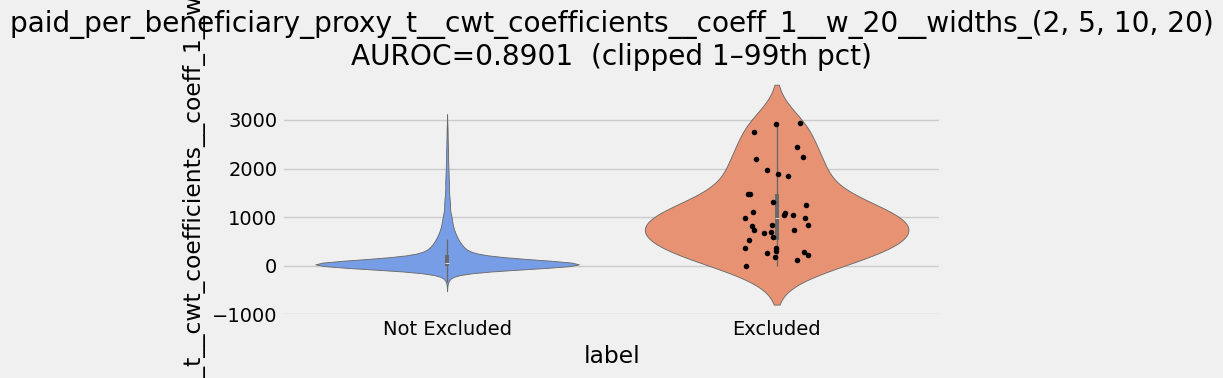

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


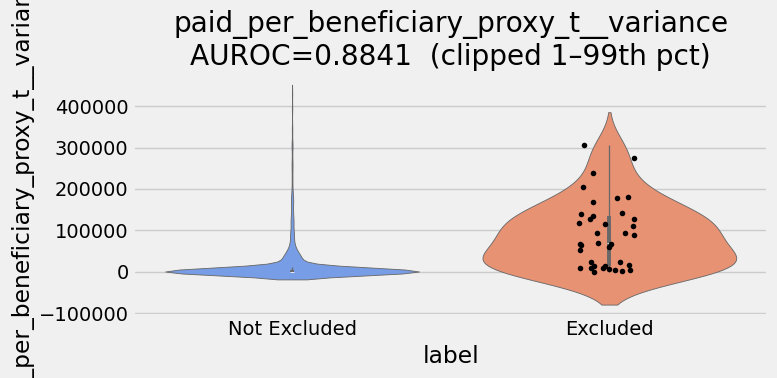

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


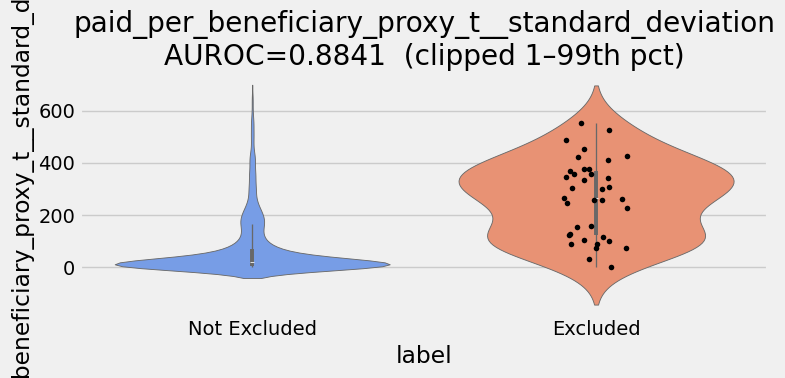

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


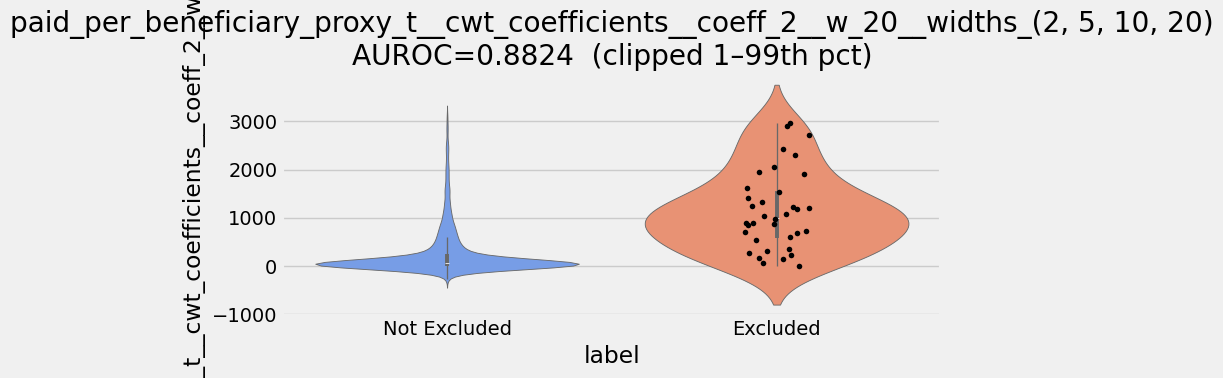

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


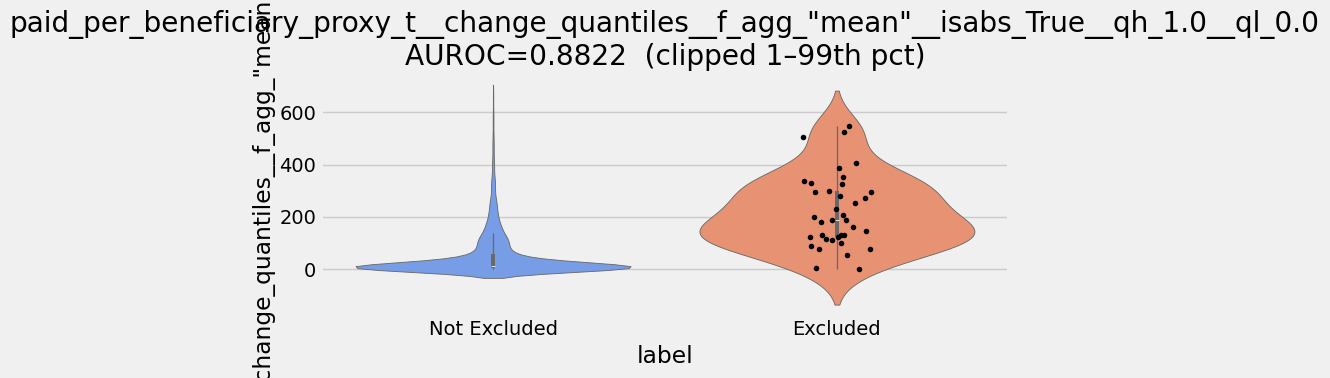

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


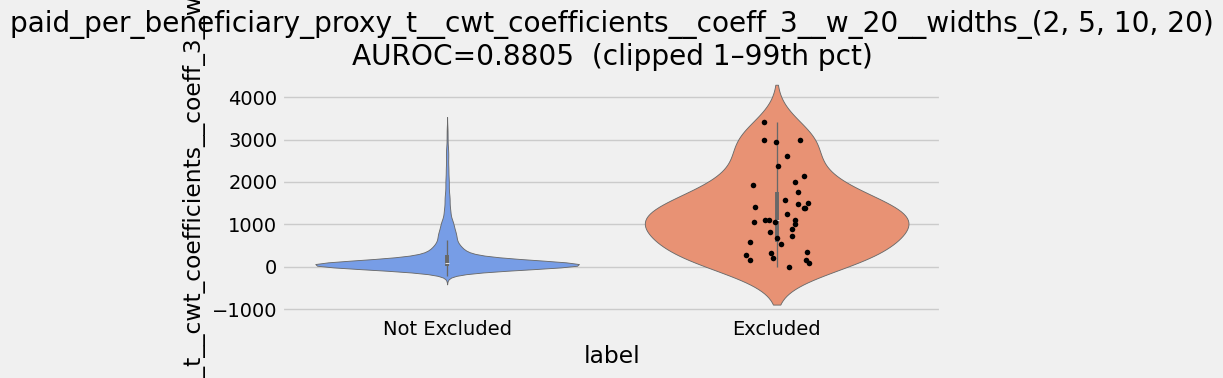

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


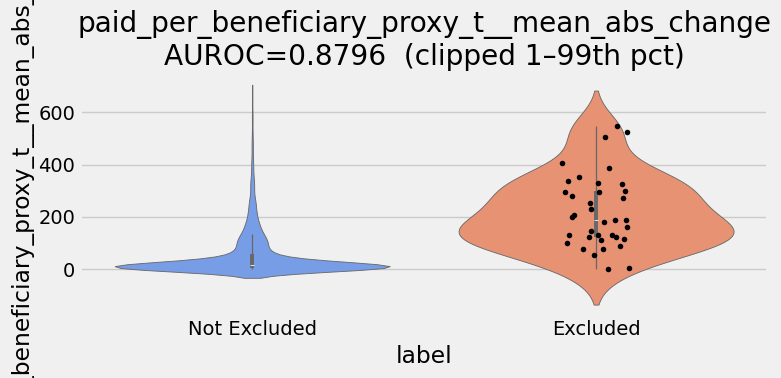

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


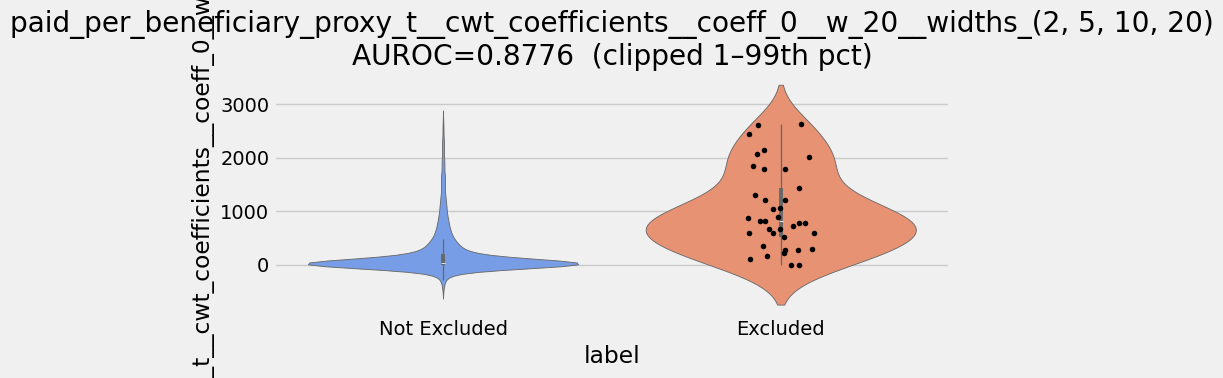

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


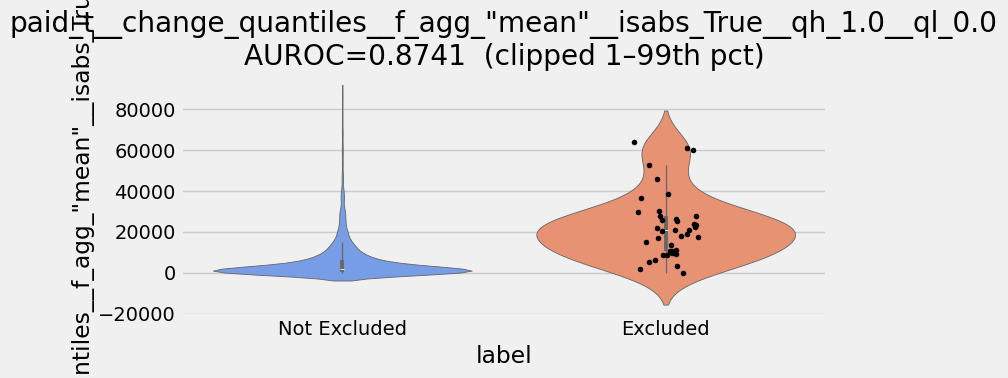

/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
/var/folders/l1/5qmzrmh136j0vqg7b2jpx0180000gn/T/ipykernel_74440/540206099.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Excluded", "Excluded"])


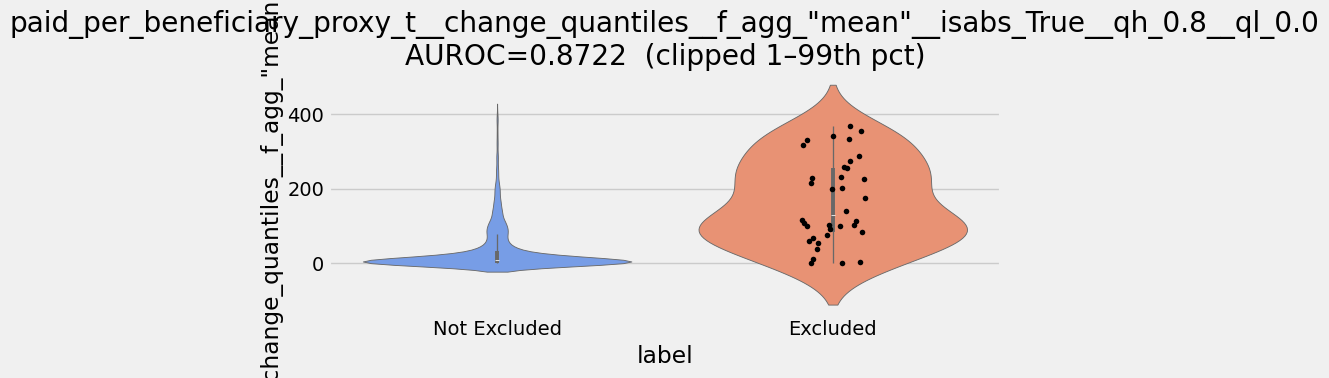

In [24]:
top10 = auroc_ts.head(10)["feature"].tolist()

for feat in top10:
    fig, ax = plt.subplots(figsize=(8, 4))
    q01 = df_ts[feat].quantile(0.01)
    q99 = df_ts[feat].quantile(0.99)
    plot_df = df_ts[df_ts[feat].between(q01, q99)]
    auc_val = auroc_ts.loc[auroc_ts["feature"] == feat, "auroc"].values[0]

    sns.violinplot(data=plot_df, x="label", y=feat, ax=ax, palette=["#6497F9", "#FB8861"], inner="box")
    sns.stripplot(data=plot_df[plot_df["label"] == 1], x="label", y=feat, ax=ax, color="black", size=4, jitter=True)
    ax.set_title(f"{feat}\nAUROC={auc_val}  (clipped 1–99th pct)")
    ax.set_xticklabels(["Not Excluded", "Excluded"])
    plt.tight_layout()
    plt.show()

In [29]:
from sklearn.ensemble import IsolationForest

# selected_with_label: index=billing_provider_npi, columns=tsfresh selected features + label
features_iso = [col for col in selected_with_label.columns if col != "label"]

X = selected_with_label[features_iso].dropna()
idx = X.index  # billing_provider_npi values

iso = IsolationForest(random_state=42)
iso.fit(X)
scores = -iso.score_samples(X)  # higher = more anomalous

results = selected_with_label.loc[idx, ["label"]].copy()
results.index.name = "billing_provider_npi"
results = results.reset_index()
results["anomaly_score"] = scores
results = results.sort_values("anomaly_score", ascending=False).reset_index(drop=True)

base_rate = results["label"].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}")

for k in [50, 100, 200, 500]:
    top_k = results.head(k)
    hits = top_k["label"].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float("nan")
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")

Base rate (LEIE prevalence): 0.0092
Top   50  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  100  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  200  |  LEIE hits:   2  |  Precision: 0.0100  |  Lift: 1.08x
Top  500  |  LEIE hits:   9  |  Precision: 0.0180  |  Lift: 1.95x


In [33]:
from sklearn.svm import OneClassSVM

features_iso = [col for col in selected_with_label.columns if col != "label"]

X = selected_with_label[features_iso].dropna()
idx = X.index

oc_svm = OneClassSVM(kernel="rbf", nu=0.15)
oc_svm.fit(X)
scores = -oc_svm.score_samples(X)  # higher = more anomalous

results = selected_with_label.loc[idx, ["label"]].copy()
results.index.name = "billing_provider_npi"
results = results.reset_index()
results["anomaly_score"] = scores
results = results.sort_values("anomaly_score", ascending=False).reset_index(drop=True)

base_rate = results["label"].mean()
print(f"Base rate (LEIE prevalence): {base_rate:.4f}")

for k in [50, 100, 200, 500]:
    top_k = results.head(k)
    hits = top_k["label"].sum()
    precision_k = hits / k
    lift = precision_k / base_rate if base_rate > 0 else float("nan")
    print(f"Top {k:>4}  |  LEIE hits: {int(hits):>3}  |  Precision: {precision_k:.4f}  |  Lift: {lift:.2f}x")


Base rate (LEIE prevalence): 0.0092
Top   50  |  LEIE hits:   0  |  Precision: 0.0000  |  Lift: 0.00x
Top  100  |  LEIE hits:   2  |  Precision: 0.0200  |  Lift: 2.16x
Top  200  |  LEIE hits:   4  |  Precision: 0.0200  |  Lift: 2.16x
Top  500  |  LEIE hits:   4  |  Precision: 0.0080  |  Lift: 0.87x
